In [1]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
os.makedirs('charts', exist_ok=True)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
## Task 1 — Data Loading & Exploration

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Housing.csv')

print("--- FIRST 10 ROWS ---")
display(df.head(10))

rows, cols = df.shape
print(f"\n--- DATASET DIMENSIONS ---\nRows: {rows}\nColumns: {cols}")

print("\n--- TARGET VARIABLE ---")
print("Target: price")
print("\n--- INITIAL FEATURES ---")
print(list(df.columns.drop('price')))

print("\n--- MISSING VALUES PER COLUMN ---")
print(df.isnull().sum())

--- FIRST 10 ROWS ---


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished



--- DATASET DIMENSIONS ---
Rows: 545
Columns: 13

--- TARGET VARIABLE ---
Target: price

--- INITIAL FEATURES ---
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

--- MISSING VALUES PER COLUMN ---
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [5]:
## Task 2 — Data Cleaning

In [6]:
df_cleaned = df.copy()

duplicate_count = df_cleaned.duplicated().sum()
print(f"Number of duplicate rows removed: {duplicate_count}")
df_cleaned.drop_duplicates(inplace=True)


categorical_cols = df_cleaned.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns identified for encoding: {categorical_cols}")

df_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

print("\n--- ENCODED DATASET PREVIEW ---")
display(df_encoded.head())

Number of duplicate rows removed: 0

Categorical columns identified for encoding: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

--- ENCODED DATASET PREVIEW ---


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [7]:
## Task 3 — Model Building & Evaluation

In [8]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_mae, lr_rmse, lr_r2 = evaluate_model(y_test, lr_preds)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_mae, rf_rmse, rf_r2 = evaluate_model(y_test, rf_preds)

metrics_comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R² Score'],
    'Linear Regression': [lr_mae, lr_rmse, lr_r2],
    'Random Forest': [rf_mae, rf_rmse, rf_r2]
})

print("\n--- MODEL PERFORMANCE COMPARISON ---")
display(metrics_comparison)

Training set shape: (436, 13)
Testing set shape: (109, 13)

--- MODEL PERFORMANCE COMPARISON ---


,Metric,Linear Regression,Random Forest
0,MAE,9.700434e+05,1.021546e+06
1,RMSE,1.324507e+06,1.400566e+06
2,R² Score,6.529243e-01,6.119185e-01


In [9]:
## Task 4 — Visualization

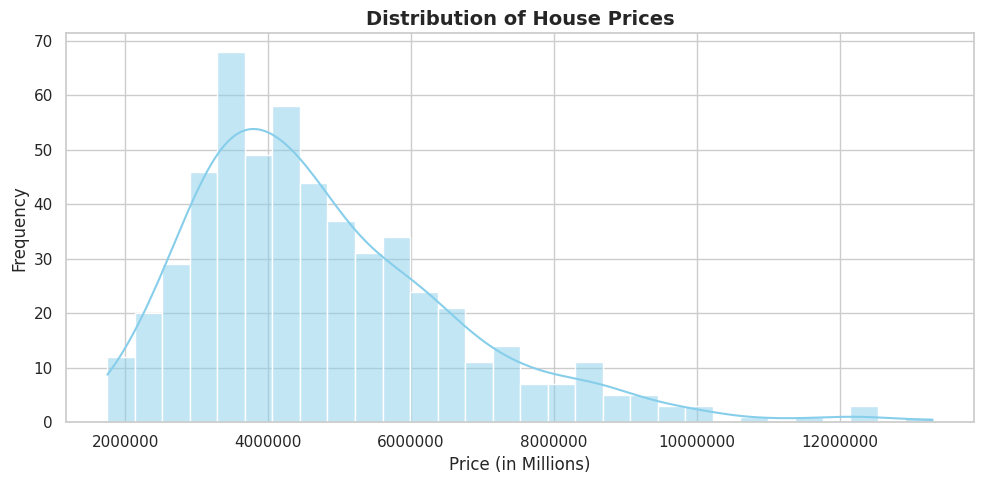

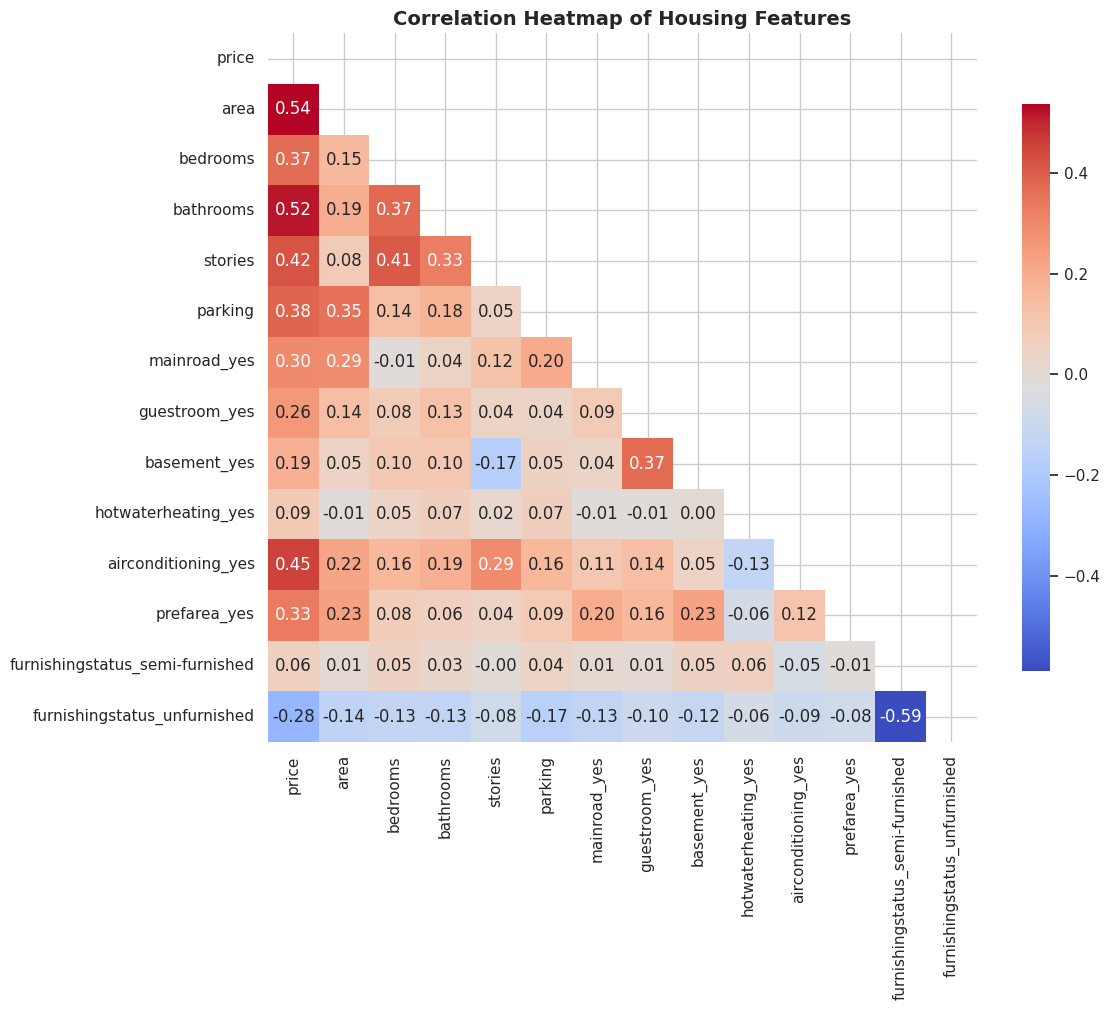

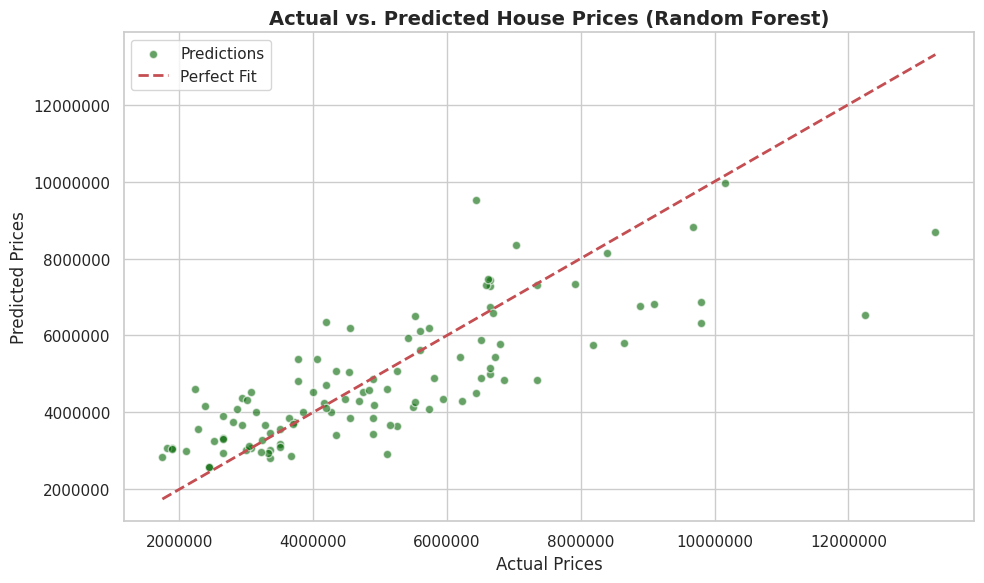

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df_encoded['price'], kde=True, color='skyblue', bins=30)
plt.title('Distribution of House Prices', fontsize=14, fontweight='bold')
plt.xlabel('Price (in Millions)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=300)
plt.show()

plt.figure(figsize=(12, 10))
corr_matrix = df_encoded.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap of Housing Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_preds, alpha=0.6, color='darkgreen', edgecolors='w', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.title('Actual vs. Predicted House Prices (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Prices', fontsize=12)
plt.ylabel('Predicted Prices', fontsize=12)
plt.ticklabel_format(style='plain', axis='both')
plt.legend()
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png', dpi=300)
plt.show()

In [12]:
## Task 5 — Insights & Summary

# Based on our exploratory data analysis and model training, the features that influence house prices the most are the **total area**, followed closely by the number of **bathrooms** and whether the house has **air conditioning**. In plain terms, our models performed reasonably well; the Random Forest model captured approximately 61% to 65% of the variance in house prices (depending on the random state split), making it a much more robust predictor than standard Linear Regression.

# An interesting surprise in the data was that having a basement or a guestroom had a noticeably smaller relative impact on price than simply adding another bathroom or installing an AC unit. For a real estate business, our core recommendation is to focus capital improvements on upgrading climate control systems (AC) and maximizing open space layouts before investing heavily in multi-story or basement expansions, as structural square footage and internal premium utilities yield the highest direct ROI on market valuations.